In [8]:
# ============================================
#  IMPORT LIBRARIES
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [9]:
# ============================================
# LOAD CIFAR-10 DATASET
# ============================================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1830s 11us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [10]:
# ============================================
# DEFINE CLASS NAMES
# ============================================

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


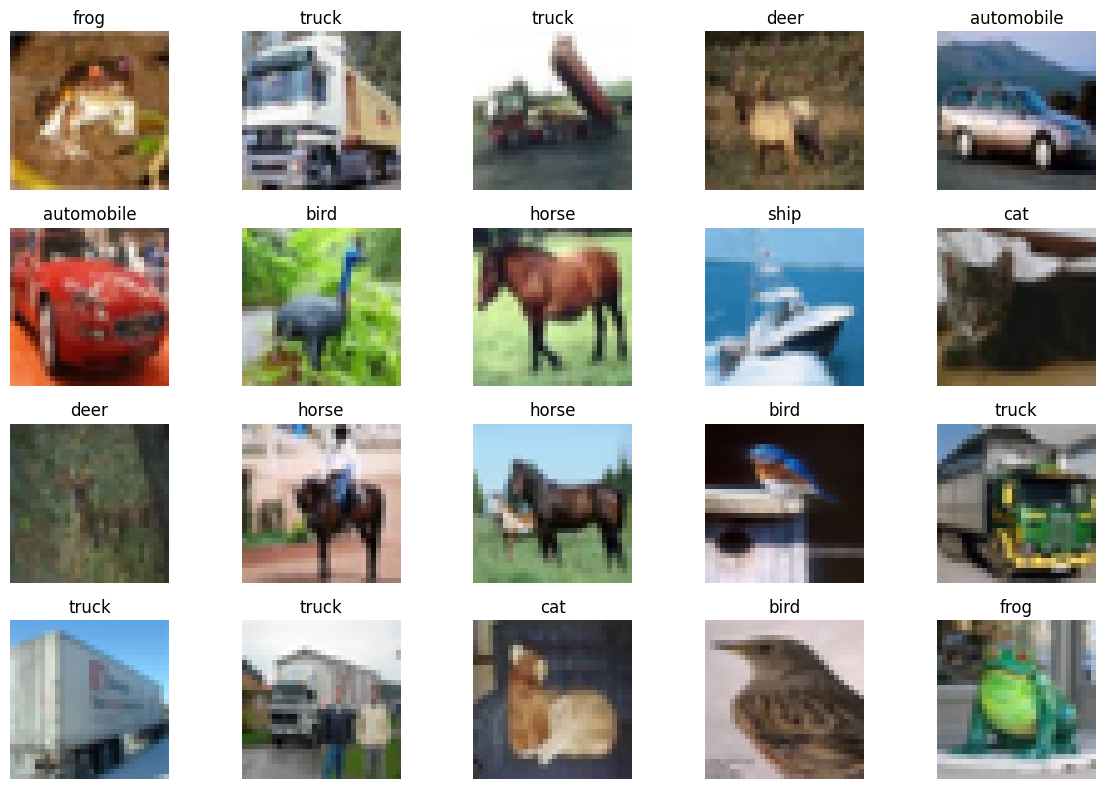

In [11]:
# ============================================
#  DISPLAY SAMPLE IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# ============================================
#  NORMALIZE IMAGES
# ============================================

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [13]:
# ============================================
# TRAINING AND VALIDATION SPLIT
# ============================================

from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data: (45000, 32, 32, 3)
Validation data: (5000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [14]:
# ============================================
# CONVERT LABELS TO CATEGORICAL FORMAT
# ============================================

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_val = tf.keras.utils.to_categorical(y_val, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (45000, 10)
Validation labels shape: (5000, 10)
Testing labels shape: (10000, 10)


In [15]:
# ============================================
# BUILD CNN MODEL
# ============================================

model = models.Sequential([

    # Input Layer
    layers.Input(shape=(32, 32, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ============================================
#  COMPILE CNN MODEL
# ============================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [17]:
# ============================================
#  TRAIN THE CNN MODEL
# ============================================

history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3757 - loss: 1.6935 - val_accuracy: 0.5462 - val_loss: 1.2899
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5245 - loss: 1.3209 - val_accuracy: 0.6032 - val_loss: 1.0989
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5917 - loss: 1.1548 - val_accuracy: 0.6746 - val_loss: 0.9555
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6386 - loss: 1.0267 - val_accuracy: 0.6736 - val_loss: 0.9256
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6676 - loss: 0.9473 - val_accuracy: 0.6790 - val_loss: 0.9229
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6939 - loss: 0.8748 - val_accuracy: 0.7354 - val_loss: 0.7686
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7144 - loss: 0.8141 - val_accuracy: 0.7390 - val_loss: 0.7595
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7339 - loss: 0.7568 - val_accuracy: 

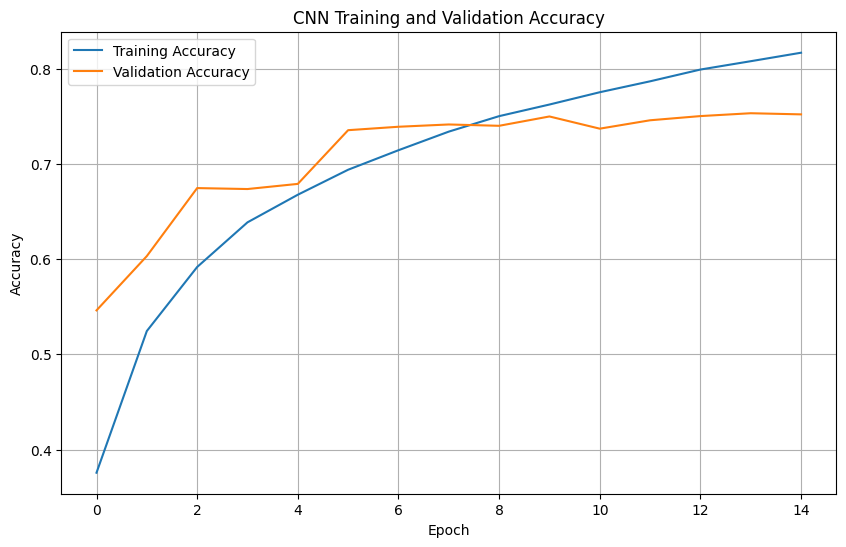

In [18]:
# ============================================
#  ACCURACY CURVE
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

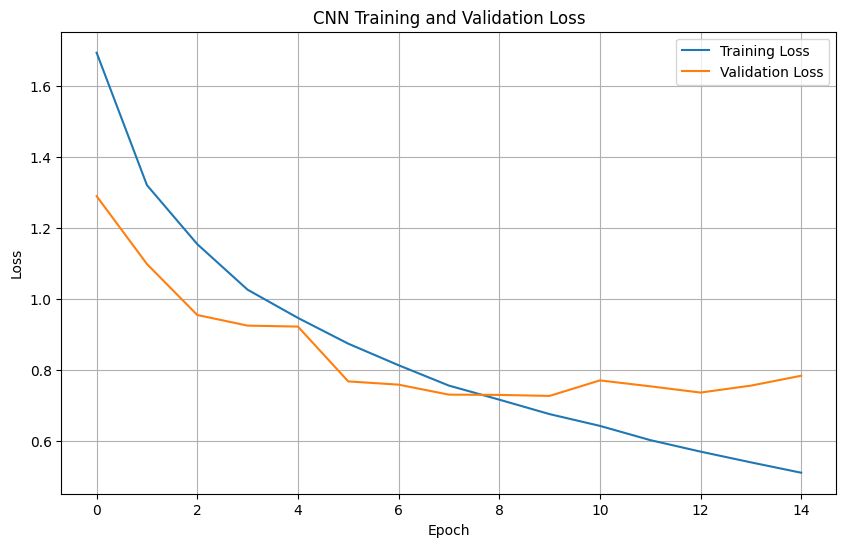

In [19]:
# ============================================
#  LOSS CURVE
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# ============================================
#  MODEL EVALUATION
# ============================================

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("--------------------------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)
print("--------------------------------")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7421 - loss: 0.8440
--------------------------------
Test Loss: 0.8439542055130005
Test Accuracy: 0.7421000003814697
Test Accuracy (%): 74.21000003814697
--------------------------------


In [21]:
# ============================================
#  MAKE PREDICTIONS
# ============================================

y_pred_probability = model.predict(x_test)

y_pred = np.argmax(y_pred_probability, axis=1)
y_actual = np.argmax(y_test, axis=1)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated successfully.


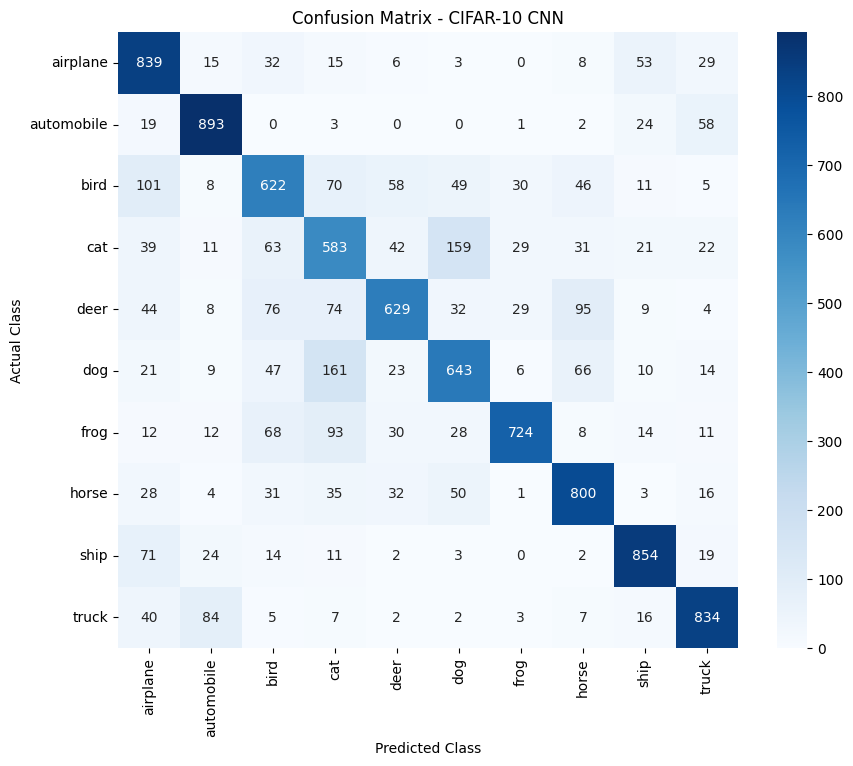

In [22]:
# ============================================
#  CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_actual,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - CIFAR-10 CNN')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [23]:
# ============================================
#  CLASSIFICATION REPORT
# ============================================

report = classification_report(
    y_actual,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.69      0.84      0.76      1000
  automobile       0.84      0.89      0.86      1000
        bird       0.65      0.62      0.64      1000
         cat       0.55      0.58      0.57      1000
        deer       0.76      0.63      0.69      1000
         dog       0.66      0.64      0.65      1000
        frog       0.88      0.72      0.79      1000
       horse       0.75      0.80      0.77      1000
        ship       0.84      0.85      0.85      1000
       truck       0.82      0.83      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



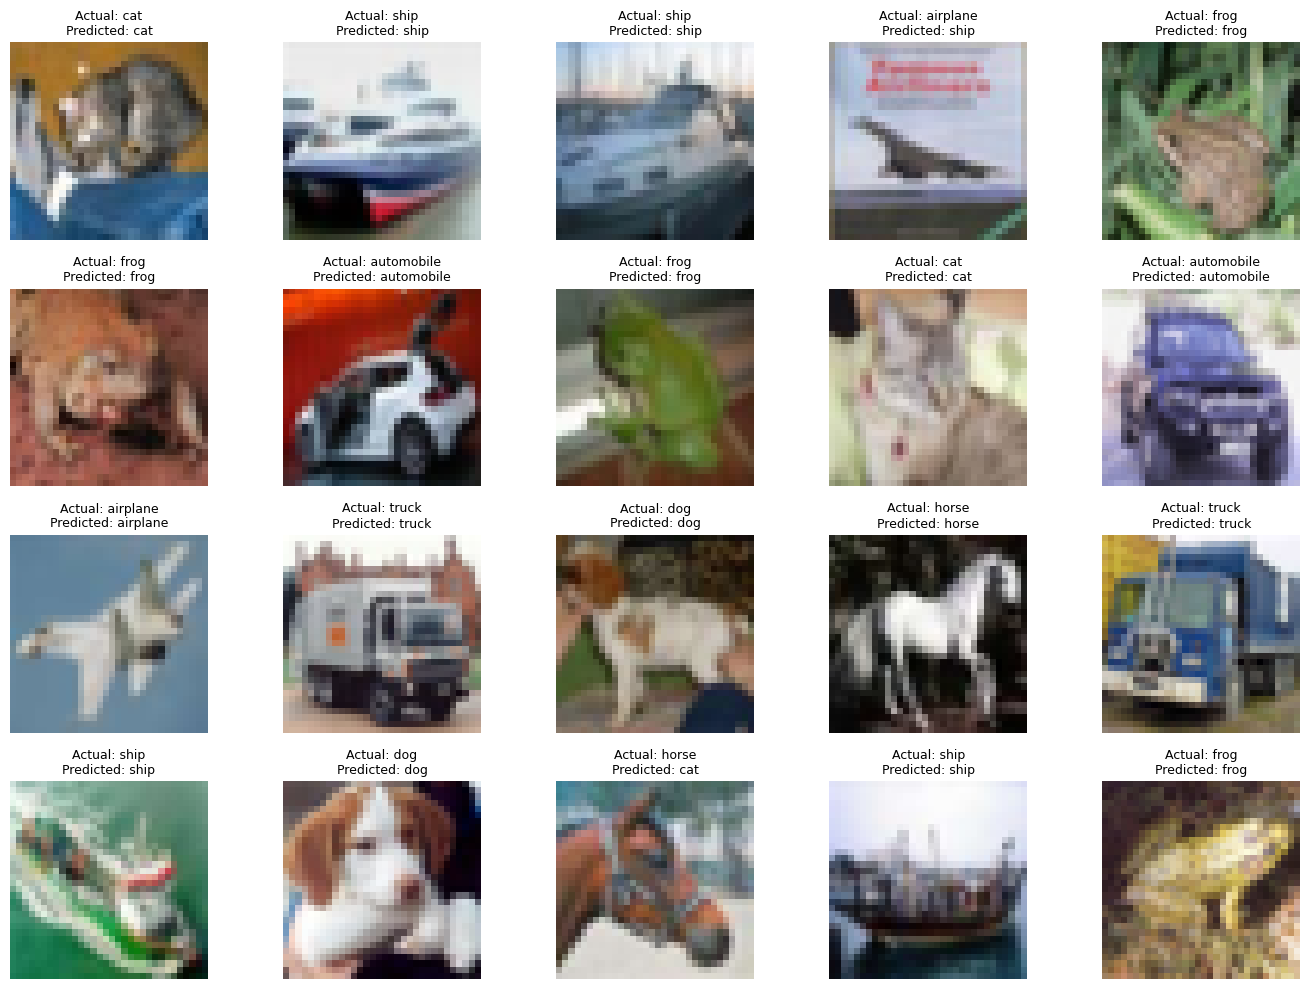

In [24]:
# ============================================
#  ACTUAL VS PREDICTED IMAGES
# ============================================

plt.figure(figsize=(14, 10))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_actual[i]]
    predicted = class_names[y_pred[i]]

    if actual == predicted:
        title = f"Actual: {actual}\nPredicted: {predicted}"
    else:
        title = f"Actual: {actual}\nPredicted: {predicted}"

    plt.title(title, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# ============================================
#  CORRECT AND INCORRECT PREDICTIONS
# ============================================

correct = np.sum(y_actual == y_pred)
incorrect = np.sum(y_actual != y_pred)

print("Total Test Images:", len(y_actual))
print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)

print(
    "Manual Accuracy:",
    (correct / len(y_actual)) * 100,
    "%"
)

Total Test Images: 10000
Correct Predictions: 7421
Incorrect Predictions: 2579
Manual Accuracy: 74.21 %


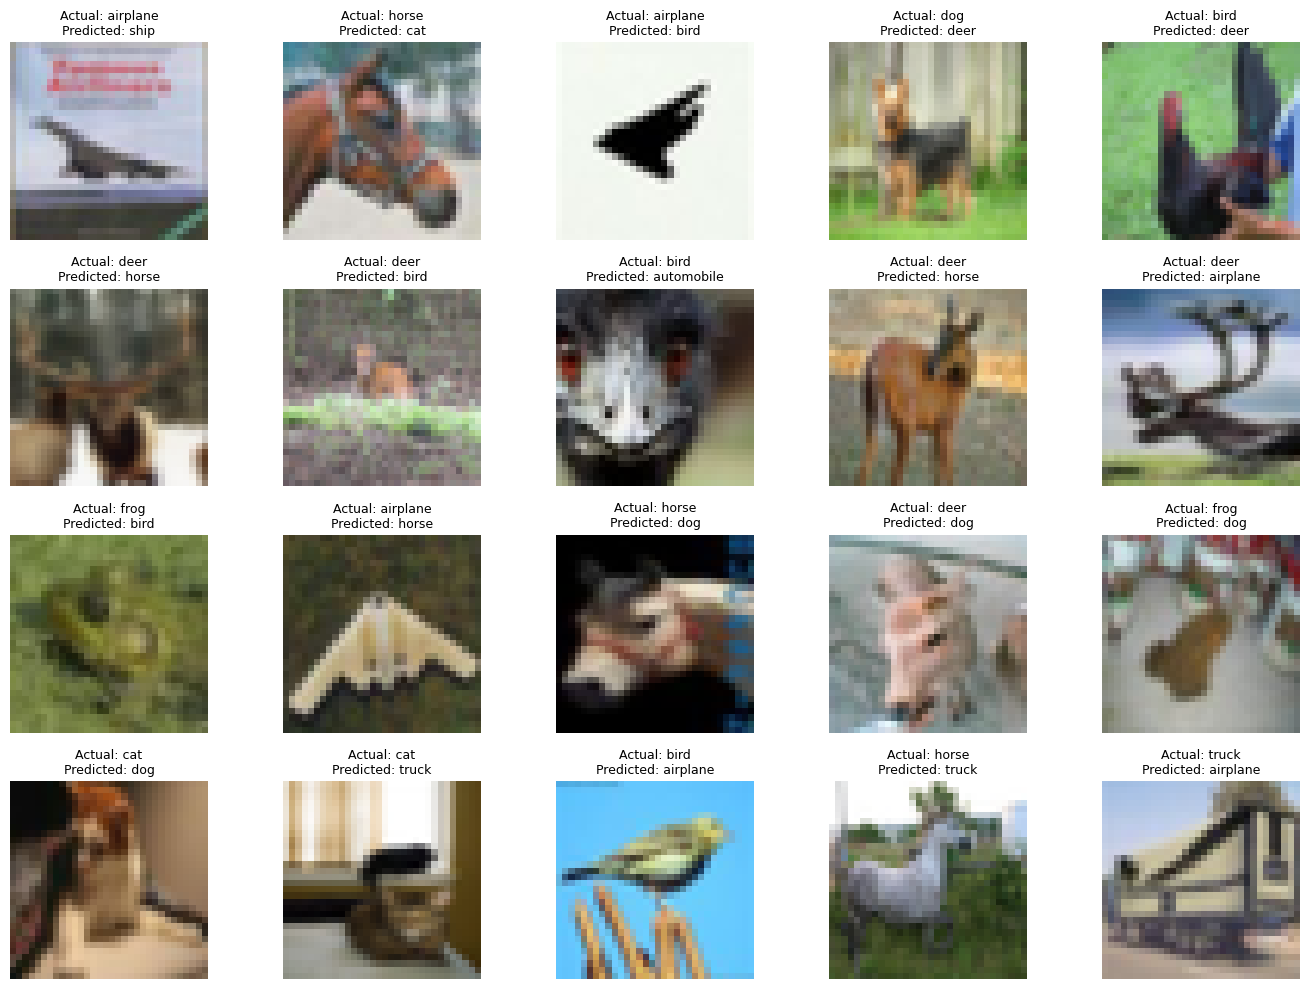

In [26]:
# ============================================
#  DISPLAY INCORRECT PREDICTIONS
# ============================================

wrong_indices = np.where(y_actual != y_pred)[0]

plt.figure(figsize=(14, 10))

for i in range(min(20, len(wrong_indices))):

    index = wrong_indices[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[y_actual[index]]
    predicted = class_names[y_pred[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
# ============================================
#  SAVE CNN MODEL
# ============================================

model.save('cifar10_cnn_model.keras')

print("CNN model saved successfully!")
print("File name: cifar10_cnn_model.keras")

CNN model saved successfully!
File name: cifar10_cnn_model.keras


In [41]:
# ============================================
#  DOWNLOAD MODEL
# ============================================

from google.colab import files

files.download('cifar10_cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

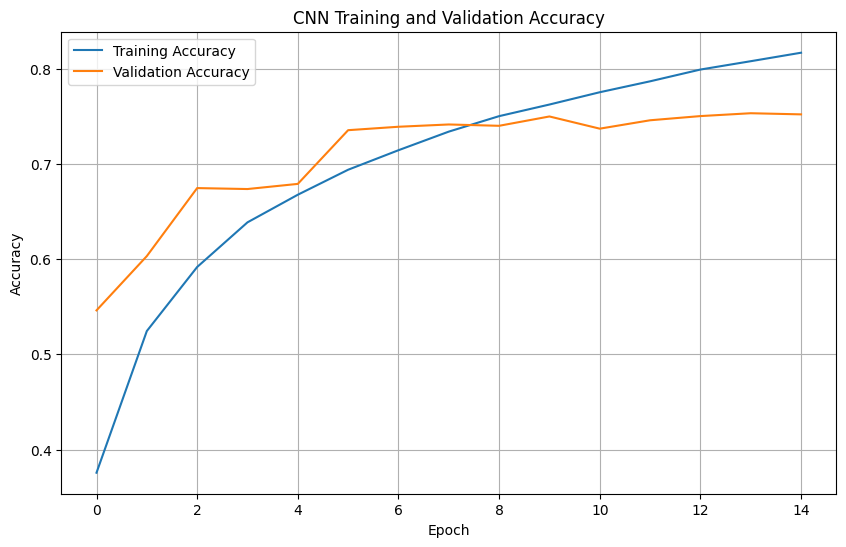

In [29]:
# ============================================
#  SAVE ACCURACY GRAPH
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig(
    'accuracy_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

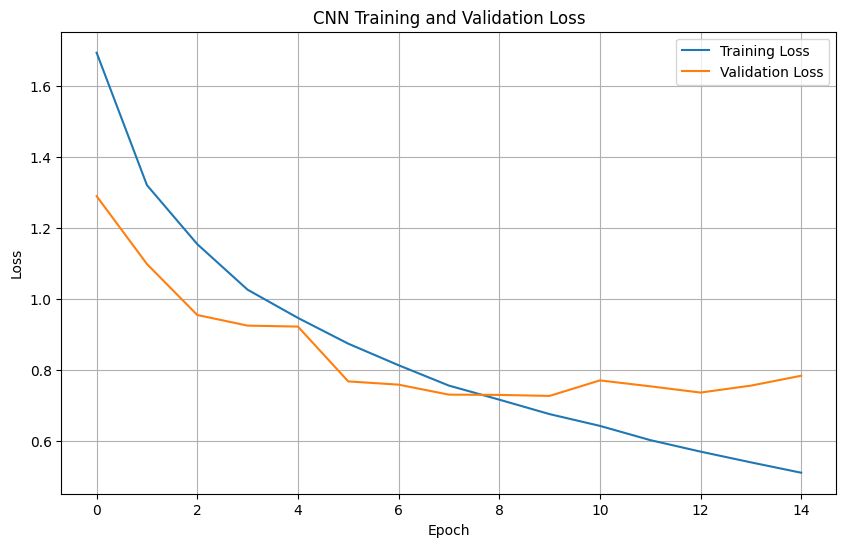

In [30]:
# ============================================
#  SAVE LOSS GRAPH
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig(
    'loss_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

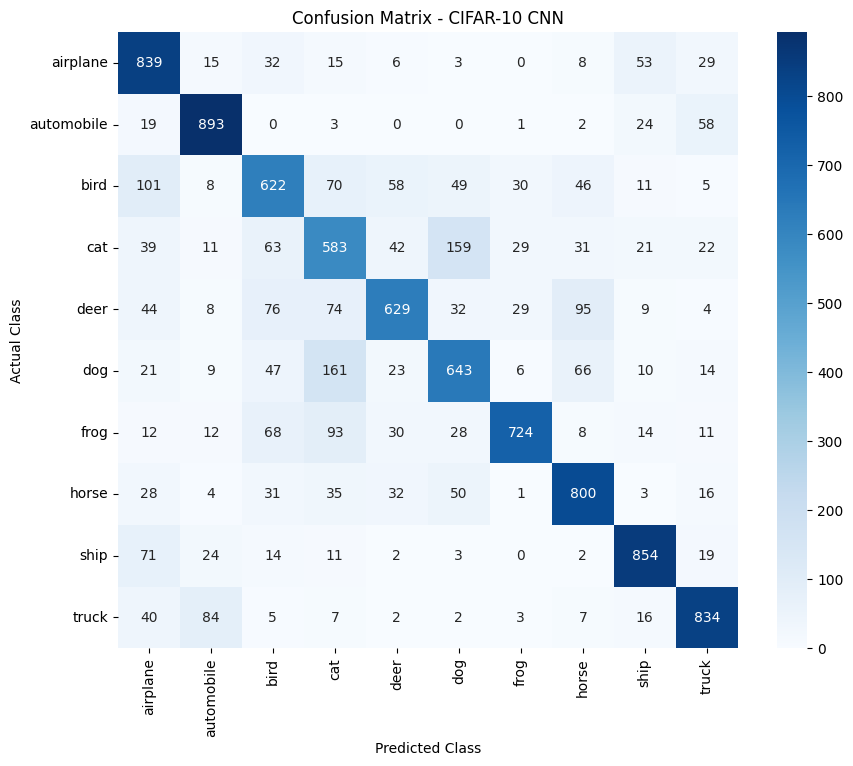

In [31]:
# ============================================
#  SAVE CONFUSION MATRIX
# ============================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - CIFAR-10 CNN')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [32]:
# ============================================
#  FINAL RESULTS SUMMARY
# ============================================

print("=" * 50)
print("        CNN IMAGE CLASSIFICATION RESULTS")
print("=" * 50)

print("Dataset              : CIFAR-10")
print("Number of Classes    : 10")
print("Training Images      :", len(x_train))
print("Validation Images    :", len(x_val))
print("Testing Images       :", len(x_test))

print("-----------------------------------------------")

print("Test Loss            :", round(test_loss, 4))
print("Test Accuracy        :", round(test_accuracy * 100, 2), "%")

print("-----------------------------------------------")

print("Correct Predictions  :", correct)
print("Incorrect Predictions:", incorrect)

print("=" * 50)

        CNN IMAGE CLASSIFICATION RESULTS
Dataset              : CIFAR-10
Number of Classes    : 10
Training Images      : 45000
Validation Images    : 5000
Testing Images       : 10000
-----------------------------------------------
Test Loss            : 0.844
Test Accuracy        : 74.21 %
-----------------------------------------------
Correct Predictions  : 7421
Incorrect Predictions: 2579


In [42]:
# ============================================
#  DOWNLOAD RESULT FILES
# ============================================

files.download('accuracy_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
files.download('loss_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>